In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf 

In [90]:
spy = yf.download('SPY', start='2014-01-01', end='2024-01-01')
spy.columns = spy.columns.droplevel(1)
print(spy.shape)
print(spy.head())

[*********************100%***********************]  1 of 1 completed

(2516, 5)
Price            Close        High         Low        Open     Volume
Date                                                                 
2014-01-02  148.580276  149.514393  148.222876  149.441280  119636900
2014-01-03  148.555908  149.132625  148.344723  148.832077   81390600
2014-01-06  148.125351  149.100071  147.897917  149.043219  108028200
2014-01-07  149.035156  149.286958  148.604655  148.718372   86144200
2014-01-08  149.067627  149.319428  148.555893  149.010762   96582300


In [91]:
spy['SMA_50'] = spy['Close'].rolling(50).mean()
spy['SMA_200'] = spy['Close'].rolling(200).mean()

In [92]:
spy['Market_Return'] = spy['Close'].pct_change()

In [94]:
# Forward return after FVG
spy['Forward_5D_Return'] = (spy['Close'].shift(-5) - spy['Close']) / spy['Close']

# Compare FVG days vs non-FVG days
fvg_returns = spy[spy['FVG_Bullish'] == True]['Forward_5D_Return']
non_fvg_returns = spy[spy['FVG_Bullish'] == False]['Forward_5D_Return']

print(f"Avg 5-day return AFTER bullish FVG: {fvg_returns.mean() * 100:.3f}%")
print(f"Avg 5-day return on NON-FVG days:   {non_fvg_returns.mean() * 100:.3f}%")
print(f"Difference: {(fvg_returns.mean() - non_fvg_returns.mean()) * 100:.3f}%")

Avg 5-day return AFTER bullish FVG: 0.066%
Avg 5-day return on NON-FVG days:   0.278%
Difference: -0.212%


In [93]:
# Calculate gap percentage
gap_pct = (spy['Low'] - spy['High'].shift(2)) / spy['High'].shift(2)

# Bullish FVG: gap exists AND gap is at least 0.2% AND 50 SMA is above 200 SMA
spy['FVG_Bullish'] = (spy['Low'] > spy['High'].shift(2)) & (gap_pct > 0.002) & (spy['SMA_50'] > spy['SMA_200'])

# Results
print(f"Total Bullish FVGs found: {spy['FVG_Bullish'].sum()}")
print(f"Total trading days: {len(spy)}")
print(f"FVG frequency: {spy['FVG_Bullish'].sum() / len(spy) * 100:.1f}% of days")

(spy['Close'].shift(-5) - spy['Close']) / spy['Close']

Total Bullish FVGs found: 302
Total trading days: 2516
FVG frequency: 12.0% of days


Date
2014-01-02    0.003936
2014-01-03    0.006835
2014-01-06   -0.003674
2014-01-07    0.001035
2014-01-08    0.006212
                ...   
2023-12-22         NaN
2023-12-26         NaN
2023-12-27         NaN
2023-12-28         NaN
2023-12-29         NaN
Name: Close, Length: 2516, dtype: float64

In [95]:
# FVG Strategy Backtest
spy['Position_FVG'] = spy['FVG_Bullish'].shift(1).rolling(5).max().fillna(0)

spy['FVG_Strategy_Return'] = spy['Position_FVG'] * spy['Market_Return']

spy['FVG_Cumulative'] = (1 + spy['FVG_Strategy_Return']).cumprod()
spy['BuyHold_Cumulative'] = (1 + spy['Market_Return']).cumprod()

# Results
total_fvg = spy['FVG_Cumulative'].iloc[-1]
total_bh = spy['BuyHold_Cumulative'].iloc[-1]

print(f"FVG Strategy Final Return:  {(total_fvg - 1) * 100:.1f}%")
print(f"Buy & Hold Final Return:     {(total_bh - 1) * 100:.1f}%")
print(f"Difference: {(total_fvg - total_bh) * 100:.1f}%")

FVG Strategy Final Return:  25.0%
Buy & Hold Final Return:     211.3%
Difference: -186.4%


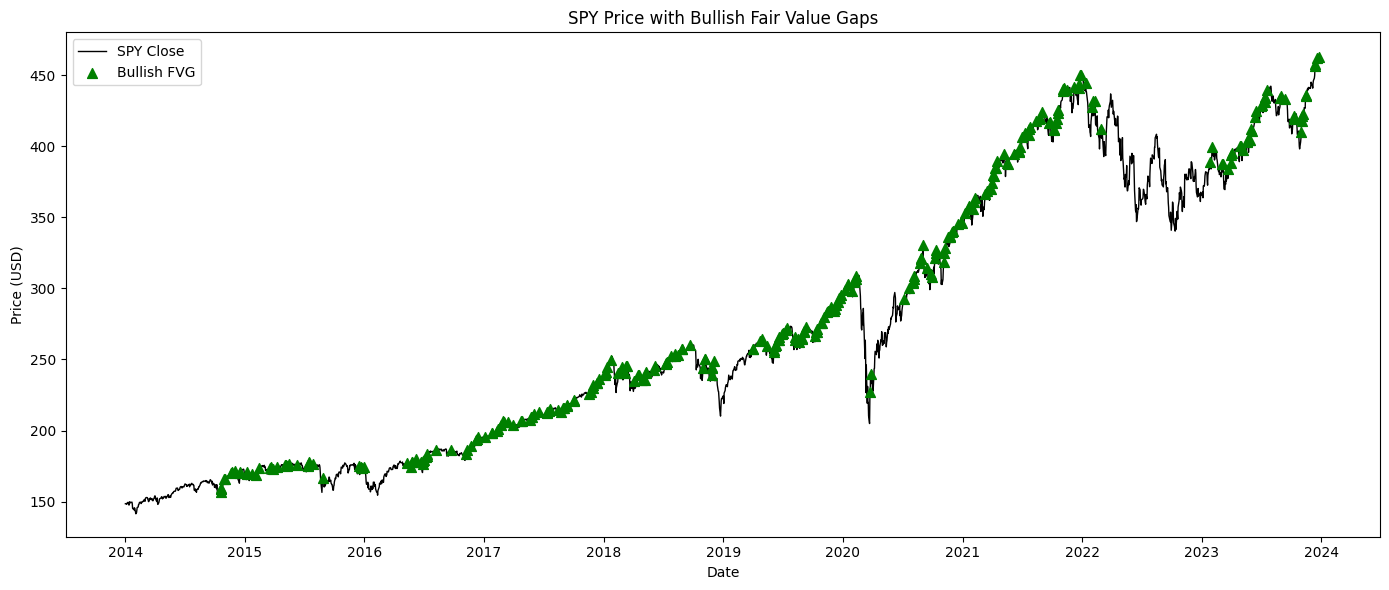

In [96]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(spy.index, spy['Close'], label='SPY Close', 
        color='black', linewidth=1)

fvg_dates = spy[spy['FVG_Bullish'] == True].index
fvg_prices = spy[spy['FVG_Bullish'] == True]['Close']

ax.scatter(fvg_dates, fvg_prices, color='green', 
           marker='^', s=50, label='Bullish FVG', zorder=5)

ax.set_title('SPY Price with Bullish Fair Value Gaps')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()

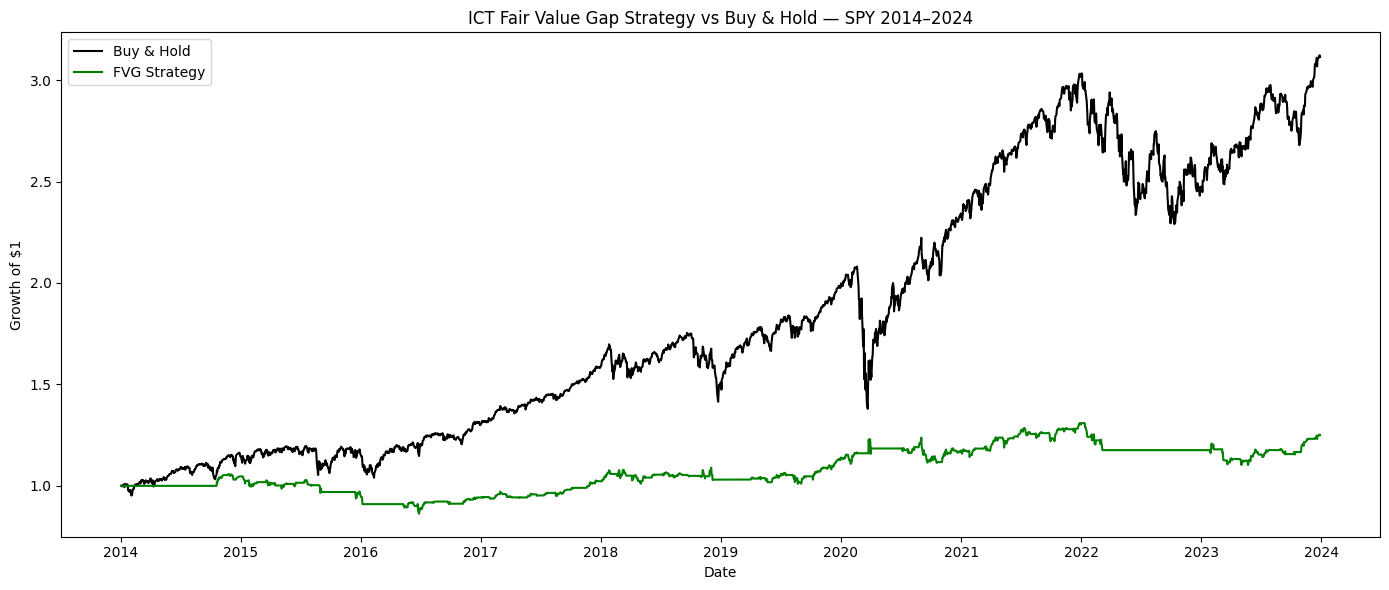

In [97]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(spy.index, spy['BuyHold_Cumulative'], label='Buy & Hold', color='black', linewidth=1.5)
ax.plot(spy.index, spy['FVG_Cumulative'], label='FVG Strategy', color='green', linewidth=1.5)

ax.set_title('ICT Fair Value Gap Strategy vs Buy & Hold — SPY 2014–2024')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.legend()
plt.tight_layout()
plt.show()

## Finding #2
Bullish FVG signals (0.2% minimum gap, uptrend filter applied) produced 
an average 5-day forward return of 0.066%, significantly below the 0.278% 
average return on non-FVG days. Even when restricted to bullish market 
conditions (SMA_50 > SMA_200), the FVG signal did not reliably predict 
price increases on SPY from 2014 to 2024. The signal appears to have 
no positive predictive edge over random days.

## Finding #3
The FVG trading strategy (0.2% minimum gap, uptrend filter, 5-day hold) 
returned 25.0% over 2014-2024 versus 211.3% for passive buy and hold,
an underperformance of 186.4%. The strategy spent approximately 88% of 
the time in cash, missing the majority of the market's long-term gains. 
These statistics clearly demonstrate the difference in a strategy vs a 
ordinary (common) buy & hold strategy, benefiting longterm. 

In [98]:
print("=" * 50)
print("NOTEBOOK 03 SUMMARY — ICT FVG STRATEGY")
print("=" * 50)
print(f"Period: 2014-2024 | Asset: SPY")
print(f"FVG signals detected: 302 (12.0% of days)")
print(f"Avg 5-day return after FVG: 0.066%")
print(f"Avg 5-day return random days: 0.278%")
print(f"FVG Strategy 10-year return: 25.0%")
print(f"Buy & Hold 10-year return: 211.3%")
print(f"Underperformance: -186.4%")

NOTEBOOK 03 SUMMARY — ICT FVG STRATEGY
Period: 2014-2024 | Asset: SPY
FVG signals detected: 302 (12.0% of days)
Avg 5-day return after FVG: 0.066%
Avg 5-day return random days: 0.278%
FVG Strategy 10-year return: 25.0%
Buy & Hold 10-year return: 211.3%
Underperformance: -186.4%
